In [1]:
import netCDF4 as nc
from pathlib import Path
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib as mpl
import matplotlib.path as mpath
import cartopy.feature as cfeature
import cmocean
import seaborn as sns
import matplotlib.colors as cols
from mpl_toolkits.basemap import Basemap

In [2]:
data0=np.load("D:\\ihespdata\\250-340fix222iii.npy")
data0 = data0[:1080]
data1=np.load("D:\\ihespdata\\340-410fix222iii2.npy")
data2=np.load("D:\\ihespdata\\410-500fix.npy")

In [3]:
dat1 = np.hstack([data0,data1])
dat2 = np.hstack([dat1,data2])

In [4]:
window_size = 60

In [5]:
resultAASW_trans2 = []
for i in range(len(dat2) - window_size + 1):
    window = dat2[i : i + window_size]
    window_average = sum(window) / window_size
    resultAASW_trans2.append(window_average)

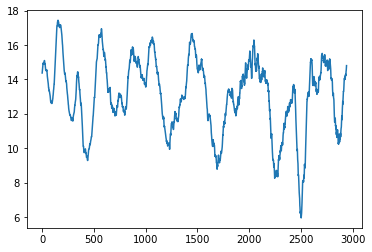

In [6]:
plt.plot(resultAASW_trans2)

In [7]:
dataHIST1=np.load("D:\\ihespdata\\crosshistory1850-1925222iii.npy")
dataHIST2=np.load("D:\\ihespdata\\crosshistory1925-2006222iii.npy")
dataHIST3=np.load("D:\\ihespdata\\crossHN2006-2038iii222.npy")
#dataHIST4=np.load("D:\\ihespdata\\crossHN2039.npy")
dataHIST4=np.load("D:\\ihespdata\\crossHN2039-2100iii2223.npy")
dat1 = np.hstack([dataHIST1[:900],dataHIST2])
dat2 = np.hstack([dat1,dataHIST3])
dat = np.hstack([dat2,dataHIST4])


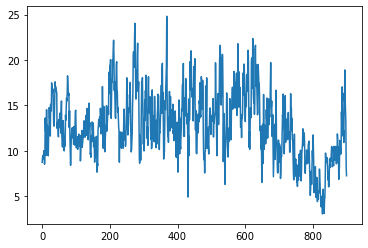

In [8]:
plt.plot(dataHIST1[:900])

In [9]:
75*12

900

In [10]:
window_size = 60
resultTNff = []
for i in range(len(dat) - window_size + 1):
    window = dat[i : i + window_size]
    window_average = sum(window) / window_size
    resultTNff.append(window_average)

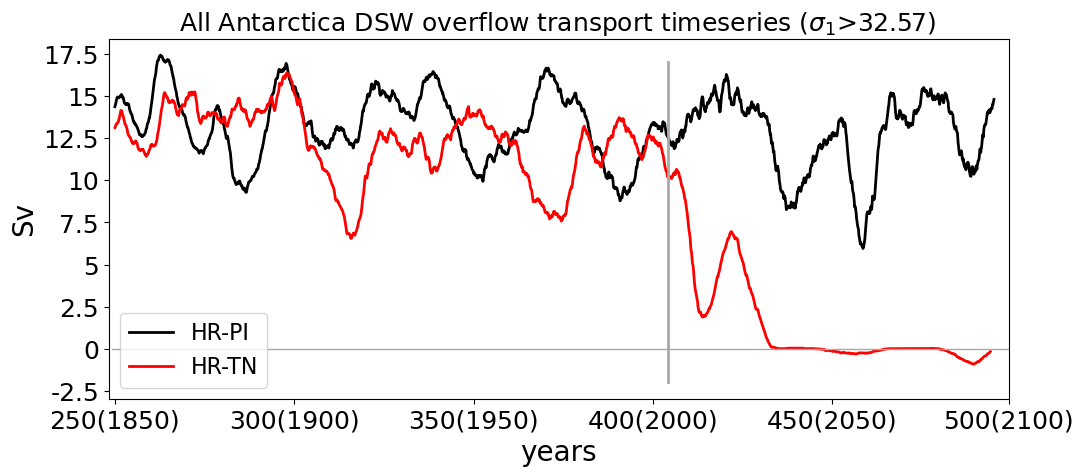

In [11]:
fig = plt.figure(figsize=(15,10), dpi=100)
ax = fig.add_axes([0.1, 0.5, 0.6, 0.36])
ax.plot(resultAASW_trans2,color = 'k',linestyle = '-', linewidth = 2, label = 'HR-PI')
ax.set_xticks([0,600,1200,1800,2400,2990])
ax.set_xticklabels(['250(1850)','300(1900)','350(1950)','400(2000)','450(2050)','500(2100)'], fontsize = 18)

ax.plot(resultTNff,color = 'red',linestyle = '-', linewidth = 2, label = 'HR-TN')
ax.plot([-10,3100],[0, 0],'darkgrey',linewidth=1)
ax.plot([1850,1850],[-2, 17],'darkgrey',linewidth=2)
ax.set_ylabel(r'Sv', fontsize = 20)
ax.set_xlabel('years', fontsize = 20)


ax.set_yticks([-2.5,0,2.5,5,7.5,10,12.5,15,17.5])
ax.set_yticklabels(['-2.5','0','2.5','5','7.5','10','12.5','15','17.5'], fontsize = 18)
ax.set_xlim((-20,2990))
#ax.set_ylim((37.75,36.0))

ax.legend(fontsize = 16) 
ax.set_title('All Antarctica DSW overflow transport timeseries ($\sigma_{1}$>32.57) ', fontsize = 18)

plt.savefig("DSWtimeseries.png",bbox_inches='tight')